## CNN Visualization

CNN visualization helps us understand what a convolutional neural network learns internally.

As an image passes through the network, each convolutional layer produces **feature maps** that highlight patterns detected by filters (such as edges, textures, or shapes). Early layers detect simple features, while deeper layers detect more complex patterns.

By visualizing these feature maps, we can see what parts of the image the network focuses on. This area of research is often called **CNN visualization** or **visual explanation**, and it is used to better understand and interpret neural network behavior.

In [37]:

import torch
import torch.nn as nn
from torch.autograd import Variable
from torchvision import models
from torchvision import transforms, utils
import numpy as np
import scipy.misc
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
import json



### Image Transformations

`transforms.Compose()` is used to apply multiple image transformations sequentially before feeding the image to the CNN.

Steps applied here:
1. **Resize** – The image is resized to **224 × 224**, which is the input size expected by **VGG16**.
2. **ToTensor** – Converts the image into a **PyTorch tensor**, since PyTorch models operate on tensors.
3. **Normalize** – The image is normalized using the **mean and standard deviation of the RGB channels** so pixel values follow a standardized scale.

These transformations are applied **in order: Resize → Tensor → Normalize** before the image is passed into the network.

In [38]:

transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])



The image contains a **Golden Retriever**, which the pretrained **ImageNet model** will later attempt to classify correctly.

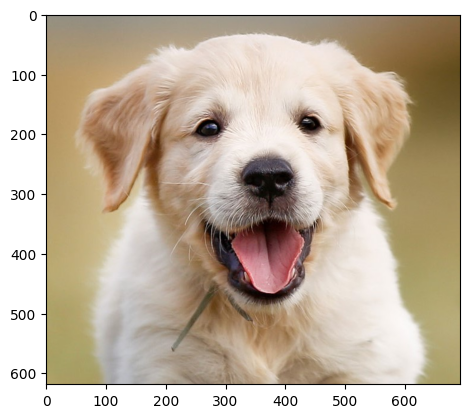

In [39]:


image = Image.open('dog.jpg')
plt.imshow(image)



## Transfer Learning vs Using a Pretrained Model

In the previous **Ants vs Bees** project, we used **transfer learning**.  
We loaded a pretrained **ResNet model**, froze most of its layers, and replaced the **final fully connected layer** so the model could classify **2 classes (ants and bees)** instead of the original **1000 ImageNet classes**.

In this **VGG example**, we are **not doing transfer learning**. We are simply using a **pretrained VGG model** to classify an image. The model still predicts among the **1000 ImageNet categories**, so when we give it an image of a dog, it can classify it as **Golden Retriever**.

However, if we wanted to use **transfer learning with VGG**, we would need to modify the final layer of the classifier.

In [40]:
vgg = models.vgg16(pretrained=True)

/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [41]:
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [42]:
CUDA = torch.cuda.is_available()
if CUDA:
    vgg = vgg.cuda()

In [43]:
#Appling the transforms on the image
image = transform(image)

In [44]:
print(image.shape)
# since it's an RGB image, so there are 3 channels. And using the transformation we resized
# the image to 224 * 224

torch.Size([3, 224, 224])


### Adding Batch Dimension

CNN models expect input in the format **(batch_size, channels, height, width)**.  
Since we are testing with **one image**, we add a batch dimension using:

```python
image = image.unsqueeze(0)
```

`unsqueeze(0)` adds a new dimension at index 0, converting the shape from  
**(3, 224, 224)** → **(1, 3, 224, 224)**, where `1` represents the batch size because there is only 1 image

In [45]:

#Add the batch size
image = image.unsqueeze(0)



In [46]:
#Wrap it up in a variable
image = Variable(image)

In [47]:


#Transfer it to the GPU
if CUDA:
    image = image.cuda()



In [48]:


print(image.shape)



torch.Size([1, 3, 224, 224])


In [49]:
output = vgg(image)

In [50]:
print(output.shape)
#1 row and 1000 columns as we have 1000 classes.

torch.Size([1, 1000])


## Why We Use `squeeze()`

The model output has shape **(1, 1000)** because the batch size is **1** (because only 1 image)and the model predicts scores for **1000 classes**.

Since we only have one image, the extra batch dimension is not needed.  
Using `squeeze(0)` removes this dimension and converts the tensor from **(1, 1000)** to **(1000)**.

This makes it easier to work with the prediction scores for the 1000 classes.

In [51]:
#Transfer the 2D Tensor to 1D
output = output.squeeze(0)

In [52]:


print(output.shape)



torch.Size([1000])


## Loading ImageNet Class Labels

The pretrained VGG model predicts among **1000 ImageNet classes**, but the output only gives **class indices** (numbers).  
To convert these indices into **actual class names**, we load the file `imagenet_class_index.json`.


This JSON file maps each **class index → corresponding class label**, allowing us to translate the model’s prediction into a human-readable category (e.g., *Golden Retriever*).


In [53]:
labels = json.load(open('imagenet_class_index.json'))

In [54]:
index = output.max(0)   # o means, along the 0 dimension

`output.max(0)` returns two things: the highest score and the index of that score.  
The index represents the predicted class among the 1000 ImageNet classes.  
We use this index to look up the actual class name (e.g., "Golden Retriever") from `imagenet_class_index.json`.

In [55]:
print(index)

torch.return_types.max(
values=tensor(17.8178, grad_fn=<MaxBackward0>),
indices=tensor(207))


In [60]:
print(labels)

{'0': ['n01440764', 'tench'], '1': ['n01443537', 'goldfish'], '2': ['n01484850', 'great_white_shark'], '3': ['n01491361', 'tiger_shark'], '4': ['n01494475', 'hammerhead'], '5': ['n01496331', 'electric_ray'], '6': ['n01498041', 'stingray'], '7': ['n01514668', 'cock'], '8': ['n01514859', 'hen'], '9': ['n01518878', 'ostrich'], '10': ['n01530575', 'brambling'], '11': ['n01531178', 'goldfinch'], '12': ['n01532829', 'house_finch'], '13': ['n01534433', 'junco'], '14': ['n01537544', 'indigo_bunting'], '15': ['n01558993', 'robin'], '16': ['n01560419', 'bulbul'], '17': ['n01580077', 'jay'], '18': ['n01582220', 'magpie'], '19': ['n01592084', 'chickadee'], '20': ['n01601694', 'water_ouzel'], '21': ['n01608432', 'kite'], '22': ['n01614925', 'bald_eagle'], '23': ['n01616318', 'vulture'], '24': ['n01622779', 'great_grey_owl'], '25': ['n01629819', 'European_fire_salamander'], '26': ['n01630670', 'common_newt'], '27': ['n01631663', 'eft'], '28': ['n01632458', 'spotted_salamander'], '29': ['n01632777', 

In [58]:
index = str(index[1].item())     # item() is used to get back the number not the tensor.
label = labels[index][1]    # we are getting the predicted label from the labels dictionary



In [ ]:
print(label)
# this is the predicted label by the model

golden_retriever


## Features vs Classifier in VGG

VGG is divided into two main parts:

**Features (`vgg.features`)**  
This part contains convolution and pooling layers that extract visual patterns from the image such as edges, textures, and object parts. These layers produce **feature maps**.

**Classifier (`vgg.classifier`)**  
This part contains fully connected layers that use the extracted features to predict the final class label (among the 1000 ImageNet classes).

In this tutorial we only use `vgg.features` because the goal is to **visualize the learned feature maps**, not to perform classification.

## Accessing VGG Feature Modules

`vgg.features.modules()` returns a generator containing the feature extractor and all its internal layers.  
After converting it to a list, the first element is the whole `Sequential` block, while the remaining elements are the actual layers (`Conv2d`, `ReLU`, `MaxPool2d`, etc.).

For visualization, we usually ignore the first `Sequential` container and keep only the individual layers.

In [66]:
module_list = list(vgg.features.modules())
module_list

[Sequential(
   (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): ReLU(inplace=True)
   (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): ReLU(inplace=True)
   (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (6): ReLU(inplace=True)
   (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (8): ReLU(inplace=True)
   (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (11): ReLU(inplace=True)
   (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (13): ReLU(inplace=True)
   (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (15): ReLU(inplace=True)
   (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   (17): Conv2d(

In [71]:

print("Printing the first element of the list \n {}\n\n\n\n\n\n".format(module_list[0]))
print("Printing the second element of the list \n {}\n\n\n\n\n\n".format(module_list[1]))
print("Printing the third element of the list \n {}\n\n\n\n\n\n".format(module_list[2]))




Printing the first element of the list 
 Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=